**Title:** AI-Based Resume Screening and Candidate Matching System

**Description:**   This project presents an AI-based Resume Screening System that automates the process of analyzing and shortlisting resumes.
It uses Natural Language Processing (NLP) techniques such as text preprocessing and TF-IDF vectorization to convert resume data into numerical form.

A machine learning model is implemented to classify resumes into different job categories, improving the efficiency of candidate filtering.
Additionally, cosine similarity is used to match resumes with a given job description and rank candidates based on relevance.

This system helps reduce manual effort in recruitment and demonstrates how AI can be applied to real-world hiring processes.

 Install & Import Libraries

In [1]:
# Install required libraries
!pip install scikit-learn pandas nltk matplotlib seaborn wordcloud plotly -q

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
from collections import Counter

# NLP
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Downloads
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


✅ All libraries imported successfully!


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


##Load & Explore the Dataset

In [3]:
# Upload your Resume.csv file when prompted
from google.colab import files
uploaded = files.upload()  # Upload Resume.csv here

Saving Resume.csv to Resume.csv


In [4]:
# Load dataset
df = pd.read_csv('Resume.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head(3)

Dataset Shape: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [5]:
# Basic info
print("=== Dataset Info ===")
print(f"Total Resumes: {len(df)}")
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"\nJob Categories ({df['Category'].nunique()} unique):")
print(df['Category'].value_counts())

=== Dataset Info ===
Total Resumes: 2484
Missing Values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Job Categories (24 unique):
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


/tmp/ipykernel_3736/919412556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


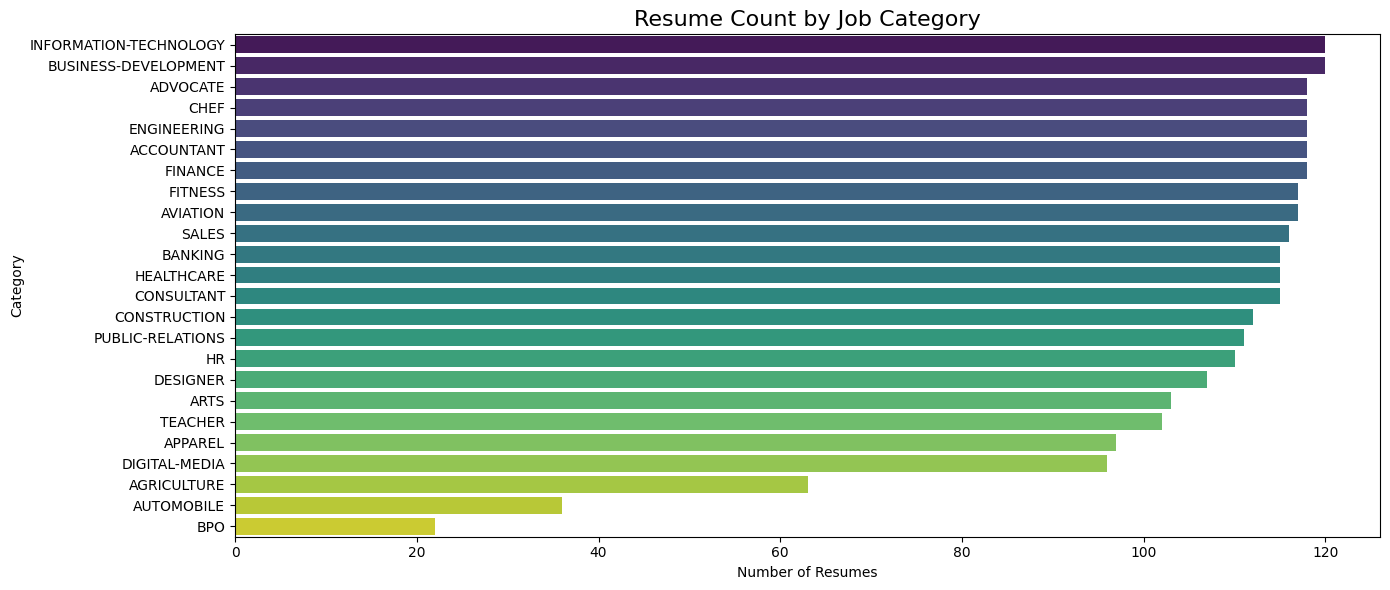

In [7]:
# Visualize category distribution
plt.figure(figsize=(14, 6))
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Resume Count by Job Category', fontsize=16)
plt.xlabel('Number of Resumes')
plt.tight_layout()
plt.show()

## Text Cleaning & Preprocessing

In [11]:
import nltk
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_resume(text):
    """Clean and preprocess resume text."""
    if pd.isna(text):
        return ""
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove phone numbers
    text = re.sub(r'\+?\d[\d\-\s]{7,}\d', '', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Lowercase
    text = text.lower()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens
               if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Cleaning resumes... (this may take a moment)")
df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)
print("Text cleaning complete!")

# Preview
print("\n--- Original ---")
print(df['Resume_str'].iloc[0][:300])
print("\n--- Cleaned ---")
print(df['cleaned_resume'].iloc[0][:300])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Cleaning resumes... (this may take a moment)
Text cleaning complete!

--- Original ---
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

--- Cleaned ---
administrator marketing associate administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfaction te


## Skill Extraction using NLP

In [12]:
# Define a comprehensive skill bank
SKILL_BANK = [
    # Programming Languages
    'python', 'java', 'javascript', 'sql', 'r', 'c++', 'c#', 'scala', 'ruby', 'php',
    # Data Science & ML
    'machine learning', 'deep learning', 'nlp', 'tensorflow', 'keras', 'pytorch',
    'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'tableau', 'power bi',
    # Data Engineering
    'spark', 'hadoop', 'airflow', 'kafka', 'aws', 'azure', 'gcp', 'docker', 'kubernetes',
    # Web Development
    'html', 'css', 'react', 'angular', 'node', 'django', 'flask', 'spring',
    # Databases
    'mysql', 'postgresql', 'mongodb', 'redis', 'oracle', 'elasticsearch',
    # Soft Skills
    'leadership', 'communication', 'teamwork', 'management', 'agile', 'scrum',
    'project management', 'problem solving', 'analytical',
    # Domain Skills
    'excel', 'word', 'powerpoint', 'git', 'linux', 'networking', 'security',
    'accounting', 'marketing', 'sales', 'customer service', 'hr', 'recruitment',
    'finance', 'blockchain', 'devops', 'testing', 'qa'
]

def extract_skills(text):
    """Extract skills from resume text."""
    text_lower = text.lower()
    found_skills = [skill for skill in SKILL_BANK if skill in text_lower]
    return found_skills

df['extracted_skills'] = df['Resume_str'].apply(extract_skills)
df['skill_count'] = df['extracted_skills'].apply(len)

print(" Skill extraction complete!")
print(f"\nAverage skills per resume: {df['skill_count'].mean():.1f}")
print(f"Max skills found in one resume: {df['skill_count'].max()}")
print(f"\nSample skills extracted from resume 1:")
print(df['extracted_skills'].iloc[0])

 Skill extraction complete!

Average skills per resume: 8.7
Max skills found in one resume: 34

Sample skills extracted from resume 1:
['r', 'aws', 'leadership', 'management', 'analytical', 'accounting', 'marketing', 'sales', 'customer service', 'hr']


/tmp/ipykernel_3736/2834610883.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skills_df, x='Frequency', y='Skill', palette='magma')


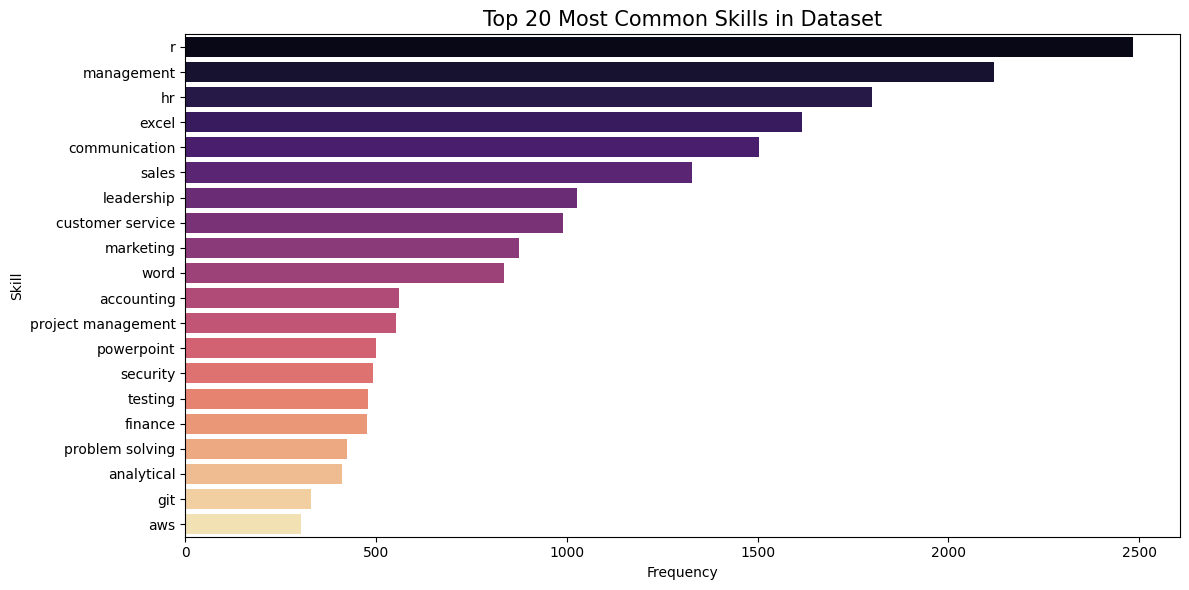

In [14]:
# Top skills across all resumes
all_skills = [skill for skills in df['extracted_skills'] for skill in skills]
skill_freq = Counter(all_skills).most_common(20)

skills_df = pd.DataFrame(skill_freq, columns=['Skill', 'Frequency'])

plt.figure(figsize=(12, 6))
sns.barplot(data=skills_df, x='Frequency', y='Skill', palette='magma')
plt.title('Top 20 Most Common Skills in Dataset', fontsize=15)
plt.tight_layout()
plt.show()

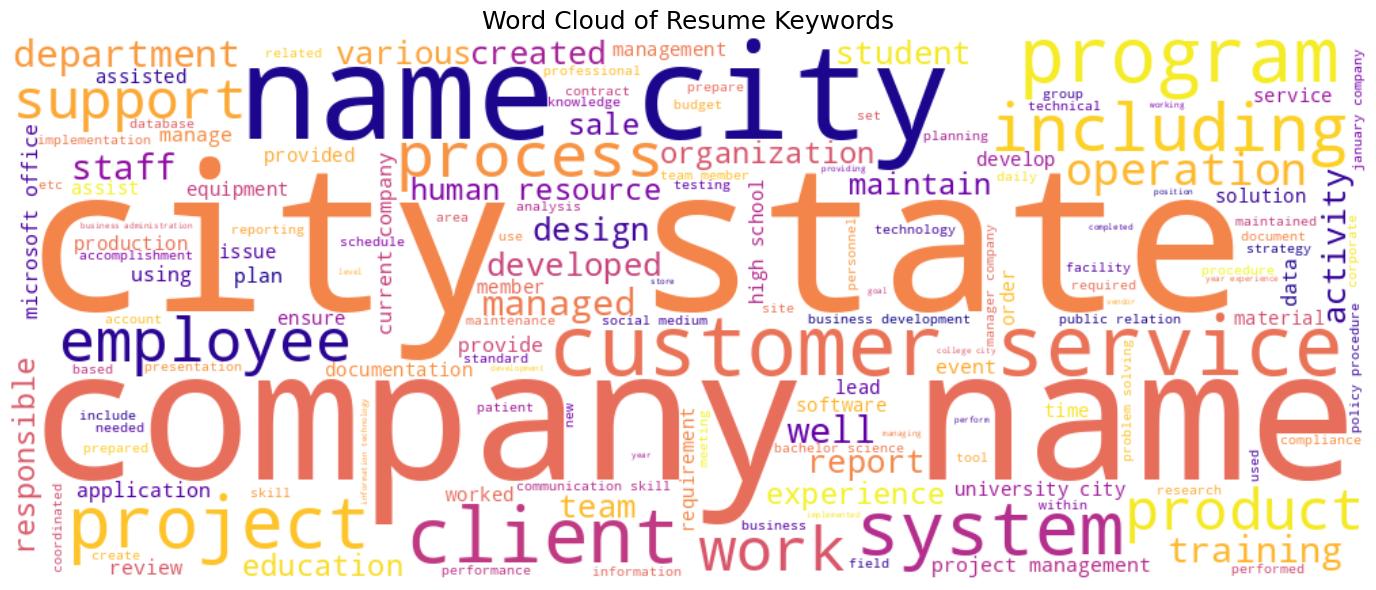

In [16]:
# WordCloud of all resume words
all_text = ' '.join(df['cleaned_resume'].values)
wordcloud = WordCloud(width=1000, height=400, background_color='white',
                      colormap='plasma', max_words=150).generate(all_text)

plt.figure(figsize=(16, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Resume Keywords', fontsize=18)
plt.tight_layout()
plt.show()

##Resume vs Job Description — Similarity Scoring

In [17]:
# ====================================================
# 🔧 CUSTOMIZE: Enter your job description here!
# ====================================================
JOB_DESCRIPTION = """
We are looking for a Data Scientist with strong experience in Python, machine learning,
and data analysis. The ideal candidate should have hands-on experience with scikit-learn,
pandas, numpy, and SQL. Knowledge of deep learning frameworks like TensorFlow or PyTorch
is a plus. Experience with data visualization tools such as Tableau or Power BI is preferred.
Strong communication skills and the ability to work in an agile team environment are required.
Experience with cloud platforms (AWS, GCP, or Azure) is a bonus.
"""

# Required skills from JD
REQUIRED_SKILLS = [
    'python', 'machine learning', 'sql', 'pandas', 'numpy',
    'scikit-learn', 'tensorflow', 'pytorch', 'tableau', 'power bi',
    'communication', 'agile', 'aws', 'gcp', 'azure'
]

print("Job Description Set!")
print(f"Required Skills: {REQUIRED_SKILLS}")

Job Description Set!
Required Skills: ['python', 'machine learning', 'sql', 'pandas', 'numpy', 'scikit-learn', 'tensorflow', 'pytorch', 'tableau', 'power bi', 'communication', 'agile', 'aws', 'gcp', 'azure']


In [19]:
# TF-IDF Vectorization
cleaned_jd = clean_resume(JOB_DESCRIPTION)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit on all resumes + JD
all_docs = df['cleaned_resume'].tolist() + [cleaned_jd]
tfidf_matrix = tfidf.fit_transform(all_docs)

# JD vector is last
jd_vector = tfidf_matrix[-1]
resume_vectors = tfidf_matrix[:-1]

# Cosine similarity
similarities = cosine_similarity(resume_vectors, jd_vector).flatten()
df['similarity_score'] = similarities
df['similarity_pct'] = (similarities * 100).round(2)

print("Similarity scoring complete!")
print(f"Score range: {similarities.min():.3f} — {similarities.max():.3f}")

Similarity scoring complete!
Score range: 0.000 — 0.223


## Rank Candidates

In [21]:
def get_missing_skills(resume_skills, required_skills):
    return [s for s in required_skills if s not in resume_skills]

def get_matched_skills(resume_skills, required_skills):
    return [s for s in required_skills if s in resume_skills]

df['matched_skills'] = df['extracted_skills'].apply(
    lambda x: get_matched_skills(x, REQUIRED_SKILLS))
df['missing_skills'] = df['extracted_skills'].apply(
    lambda x: get_missing_skills(x, REQUIRED_SKILLS))
df['matched_count'] = df['matched_skills'].apply(len)

# Composite score (70% TF-IDF similarity + 30% skill match ratio)
df['skill_match_ratio'] = df['matched_count'] / len(REQUIRED_SKILLS)
df['composite_score'] = (0.7 * df['similarity_score'] + 0.3 * df['skill_match_ratio']).round(4)

# Rank
df['rank'] = df['composite_score'].rank(ascending=False).astype(int)
ranked_df = df.sort_values('composite_score', ascending=False).reset_index(drop=True)

print("Ranking complete!")

Ranking complete!


In [22]:
# Display Top 10 Candidates
print("TOP 10 CANDIDATES")
print("=" * 70)

display_cols = ['rank', 'Category', 'similarity_pct', 'matched_count',
                'matched_skills', 'missing_skills', 'composite_score']

top10 = ranked_df[display_cols].head(10)
top10.index = top10['rank']
display(top10)

TOP 10 CANDIDATES


,rank,Category,similarity_pct,matched_count,matched_skills,missing_skills,composite_score
rank,,,,,,,
1,1,AGRICULTURE,16.04,8,"[python, sql, pandas, scikit-learn, tensorflow...","[machine learning, numpy, pytorch, power bi, a...",0.2723
2,2,AGRICULTURE,22.25,5,"[python, sql, pandas, agile, aws]","[machine learning, numpy, scikit-learn, tensor...",0.2558
3,3,ENGINEERING,22.01,5,"[python, machine learning, sql, pandas, tableau]","[numpy, scikit-learn, tensorflow, pytorch, pow...",0.2540
4,4,CONSULTANT,20.99,5,"[python, machine learning, sql, agile, azure]","[pandas, numpy, scikit-learn, tensorflow, pyto...",0.2469
5,5,INFORMATION-TECHNOLOGY,18.88,5,"[python, sql, tableau, aws, azure]","[machine learning, pandas, numpy, scikit-learn...",0.2322
6,6,AUTOMOBILE,17.83,5,"[python, sql, pandas, numpy, tableau]","[machine learning, scikit-learn, tensorflow, p...",0.2248
7,7,DIGITAL-MEDIA,18.24,4,"[python, sql, tableau, power bi]","[machine learning, pandas, numpy, scikit-learn...",0.2077
8,8,INFORMATION-TECHNOLOGY,18.15,4,"[sql, communication, agile, aws]","[python, machine learning, pandas, numpy, scik...",0.2070
9,9,BANKING,14.29,5,"[sql, communication, agile, aws, azure]","[python, machine learning, pandas, numpy, scik...",0.2001


In [24]:
# Visualize Top 15 candidate scores
top15 = ranked_df.head(15).copy()
top15['label'] = top15['Category'] + ' #' + top15.index.astype(str)

fig = px.bar(
    top15,
    x='composite_score',
    y='label',
    orientation='h',
    color='composite_score',
    color_continuous_scale='Viridis',
    title='Top 15 Candidates — Composite Fit Score',
    labels={'composite_score': 'Fit Score', 'label': 'Candidate'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
fig.show()

In [25]:
# Detailed report for the TOP candidate
best = ranked_df.iloc[0]

print("=" * 60)
print("🥇 BEST CANDIDATE DETAILED REPORT")
print("=" * 60)
print(f"Category      : {best['Category']}")
print(f"Similarity    : {best['similarity_pct']}%")
print(f"Composite Score: {best['composite_score']}")
print(f"\n✅ Matched Skills ({best['matched_count']}):")
for s in best['matched_skills']:
    print(f"   • {s}")
print(f"\n❌ Missing Skills ({len(best['missing_skills'])}):")
for s in best['missing_skills']:
    print(f"   • {s}")
print("\n📝 Resume Snippet:")
print(best['Resume_str'][:500] + '...')

🥇 BEST CANDIDATE DETAILED REPORT
Category      : AGRICULTURE
Similarity    : 16.04%
Composite Score: 0.2723

✅ Matched Skills (8):
   • python
   • sql
   • pandas
   • scikit-learn
   • tensorflow
   • tableau
   • communication
   • agile

❌ Missing Skills (7):
   • machine learning
   • numpy
   • pytorch
   • power bi
   • aws
   • gcp
   • azure

📝 Resume Snippet:
           SOFTWARE DEVELOPER         Professional Summary    Enthusiastic computer engineer eager to contribute to team success through hard work, attention to detail and excellent organizational skills. Technical professional with complete understanding of entire software development life cycle. Respectful self-motivator gifted at finding reliable solutions for software issues. Experienced in c#, python, HTML, SQL, node.js/javascript and working knowledge of Restful API design & implementation...




## ML Classification — Predict Job Category

In [26]:
# Encode categories
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['Category'])

# TF-IDF features
tfidf_clf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X = tfidf_clf.fit_transform(df['cleaned_resume'])
y = df['category_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 1987
Testing samples : 497


In [27]:
# Train Logistic Regression classifier
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"✅ Logistic Regression Accuracy: {acc_lr*100:.2f}%")

# Train Naive Bayes classifier
print("Training Naive Bayes...")
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"✅ Naive Bayes Accuracy: {acc_nb*100:.2f}%")

# Best model
best_model = lr if acc_lr >= acc_nb else nb
best_pred = y_pred_lr if acc_lr >= acc_nb else y_pred_nb
best_name = 'Logistic Regression' if acc_lr >= acc_nb else 'Naive Bayes'
print(f"\n🏆 Best Model: {best_name}")

Training Logistic Regression...
✅ Logistic Regression Accuracy: 64.99%
Training Naive Bayes...
✅ Naive Bayes Accuracy: 56.74%

🏆 Best Model: Logistic Regression


In [28]:
# Classification Report
print(f"\n📊 Classification Report ({best_name}):")
print(classification_report(y_test, best_pred,
      target_names=le.classes_))


📊 Classification Report (Logistic Regression):
                        precision    recall  f1-score   support

            ACCOUNTANT       0.65      0.83      0.73        24
              ADVOCATE       0.31      0.46      0.37        24
           AGRICULTURE       1.00      0.38      0.56        13
               APPAREL       0.50      0.11      0.17        19
                  ARTS       0.50      0.29      0.36        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.85      0.71      0.77        24
               BANKING       0.88      0.61      0.72        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.54      0.92      0.68        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.85      0.77      0.81        22
            CONSULTANT       0.45      0.22      0.29        23
              DESIGNER       0.81      0.81      0.81  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



/tmp/ipykernel_3736/2855296182.py:11: UserWarning:

Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.



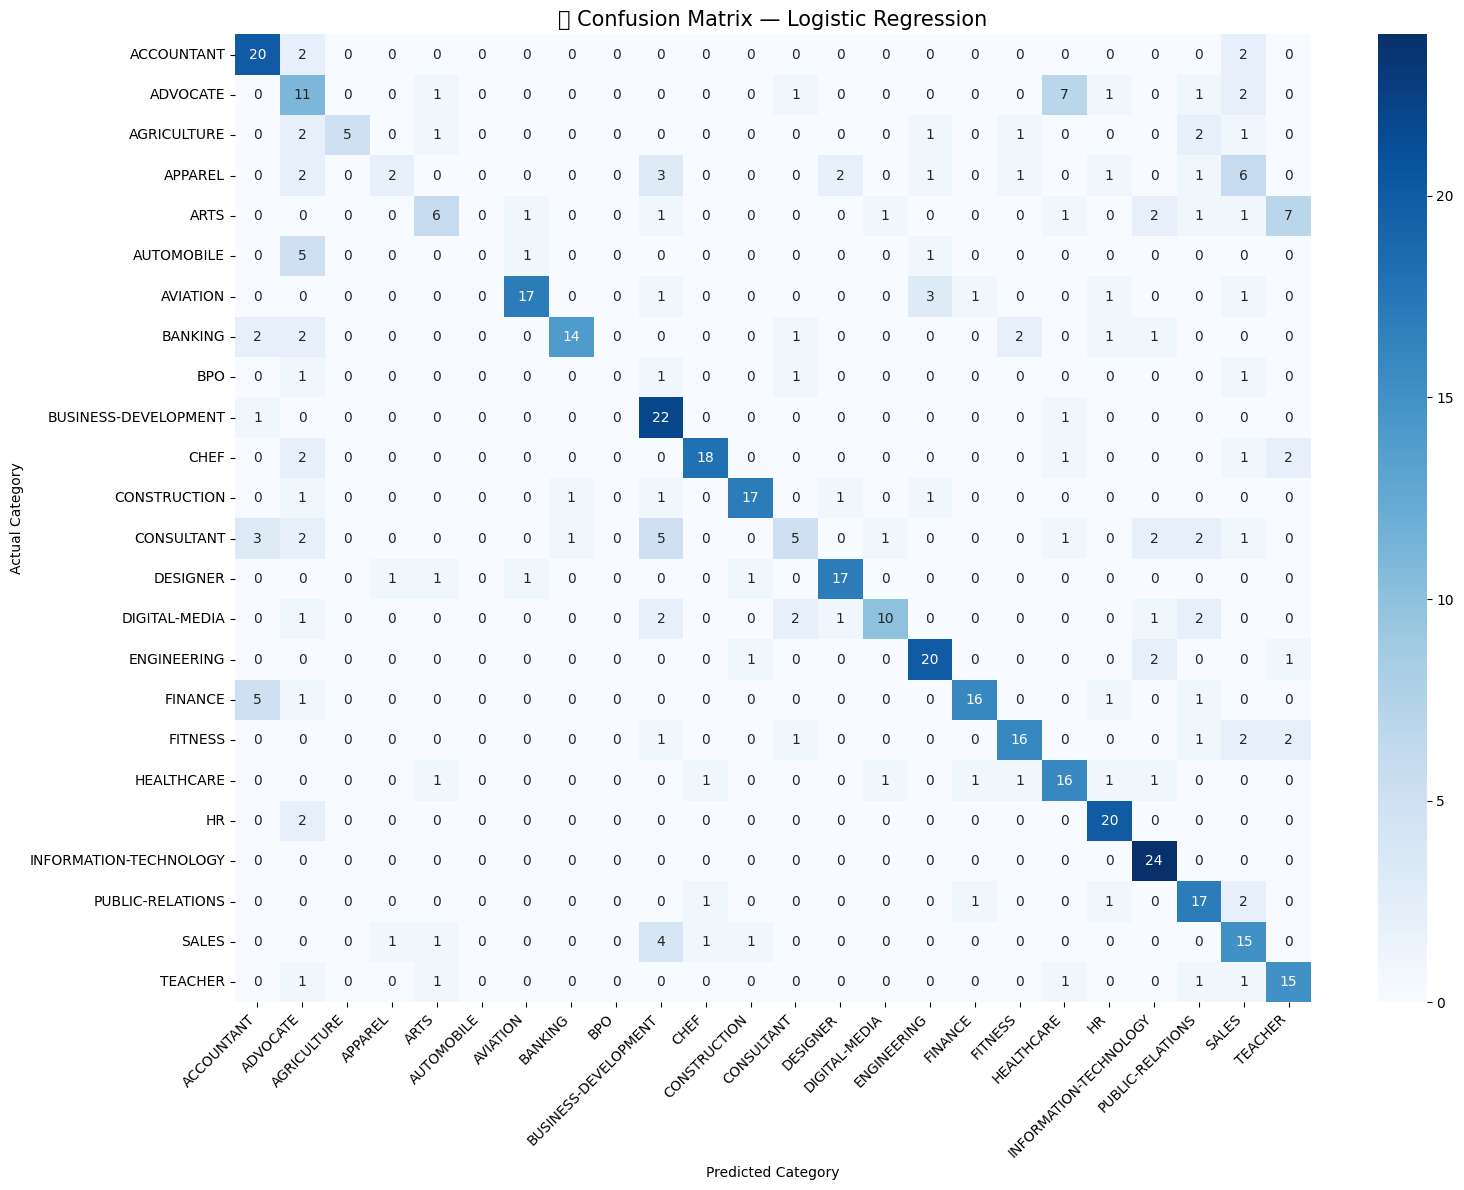

In [29]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'🔷 Confusion Matrix — {best_name}', fontsize=15)
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## EDA & Insights

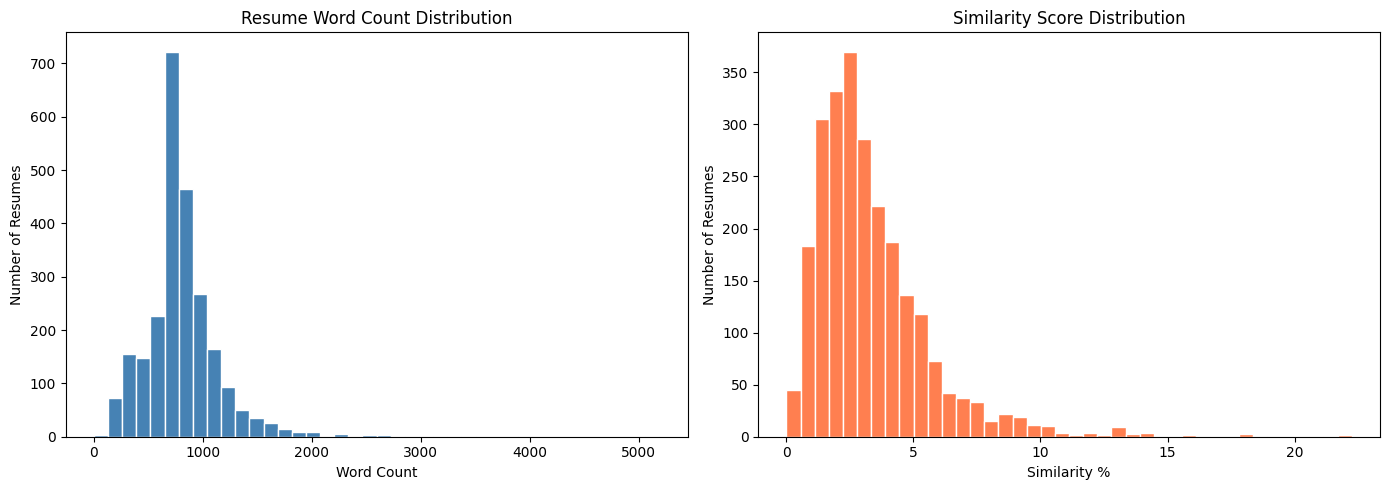

In [30]:
# Resume length distribution
df['resume_length'] = df['Resume_str'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['resume_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Resumes')

axes[1].hist(df['similarity_pct'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Similarity Score Distribution')
axes[1].set_xlabel('Similarity %')
axes[1].set_ylabel('Number of Resumes')

plt.tight_layout()
plt.show()

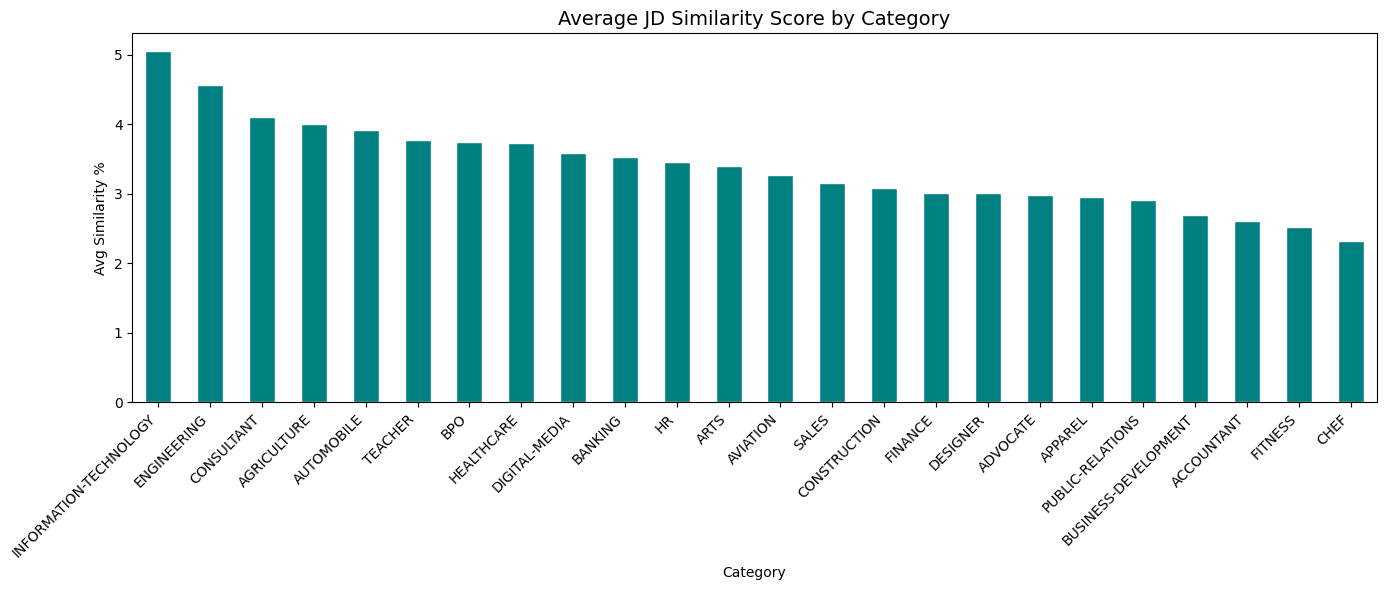

In [38]:
# Average similarity by category
cat_sim = df.groupby('Category')['similarity_pct'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
cat_sim.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Average JD Similarity Score by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Avg Similarity %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

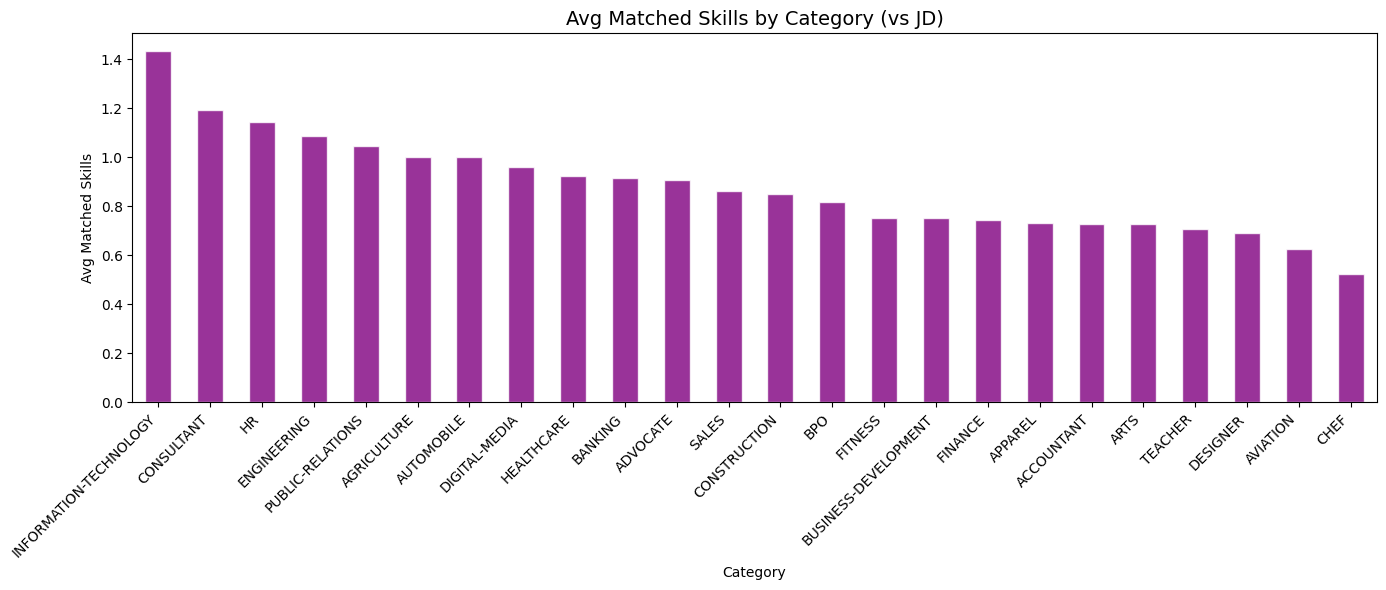

In [33]:
# Skill match count by category
cat_skills = df.groupby('Category')['matched_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
cat_skills.plot(kind='bar', color='purple', edgecolor='white', alpha=0.8)
plt.title('Avg Matched Skills by Category (vs JD)', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Avg Matched Skills')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Interactive Candidate Screener

In [34]:
def screen_candidates(job_description, required_skills_list, top_n=10, filter_category=None):
    """
    Full pipeline: Input a job description → Get ranked candidates.

    Args:
        job_description  : str — Job description text
        required_skills_list : list — Key skills required
        top_n            : int — Number of top candidates to return
        filter_category  : str or None — Filter by resume category
    """
    temp_df = df.copy()
    if filter_category:
        temp_df = temp_df[temp_df['Category'].str.lower() == filter_category.lower()]
        if len(temp_df) == 0:
            print(f"⚠️ No resumes found for category: {filter_category}")
            return

    # TF-IDF similarity
    cleaned_jd = clean_resume(job_description)
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    docs = temp_df['cleaned_resume'].tolist() + [cleaned_jd]
    mat = vec.fit_transform(docs)
    sims = cosine_similarity(mat[:-1], mat[-1]).flatten()

    temp_df = temp_df.copy()
    temp_df['sim'] = sims

    # Skill match
    req = [s.lower() for s in required_skills_list]
    temp_df['matched'] = temp_df['extracted_skills'].apply(
        lambda x: [s for s in req if s in x])
    temp_df['missing'] = temp_df['extracted_skills'].apply(
        lambda x: [s for s in req if s not in x])
    temp_df['skill_ratio'] = temp_df['matched'].apply(len) / max(len(req), 1)
    temp_df['score'] = (0.7 * temp_df['sim'] + 0.3 * temp_df['skill_ratio']).round(4)

    results = temp_df.nlargest(top_n, 'score').reset_index(drop=True)

    print(f"\n{'='*65}")
    print(f"  🎯 TOP {top_n} CANDIDATES FOR YOUR JOB DESCRIPTION")
    print(f"{'='*65}")

    for i, row in results.iterrows():
        print(f"\n#{i+1} | Category: {row['Category']} | Score: {row['score']} | Similarity: {round(row['sim']*100, 1)}%")
        print(f"   ✅ Matched Skills  : {row['matched'] or 'None'}")
        print(f"   ❌ Missing Skills  : {row['missing'] or 'None'}")

    return results

print("✅ Screener function ready!")

✅ Screener function ready!


In [37]:

my_jd = """
Looking for a Java Backend Developer with experience in Spring Boot,
microservices, REST APIs, SQL, Docker, Kubernetes, and AWS.
Excellent communication and agile teamwork required.
"""

my_skills = ['java', 'spring', 'sql', 'docker', 'kubernetes', 'aws', 'communication', 'agile']

results = screen_candidates(my_jd, my_skills, top_n=5)


  🎯 TOP 5 CANDIDATES FOR YOUR JOB DESCRIPTION

#1 | Category: INFORMATION-TECHNOLOGY | Score: 0.4313 | Similarity: 29.5%
   ✅ Matched Skills  : ['java', 'spring', 'sql', 'aws', 'communication', 'agile']
   ❌ Missing Skills  : ['docker', 'kubernetes']

#2 | Category: BANKING | Score: 0.389 | Similarity: 18.1%
   ✅ Matched Skills  : ['java', 'sql', 'docker', 'kubernetes', 'aws', 'communication', 'agile']
   ❌ Missing Skills  : ['spring']

#3 | Category: AVIATION | Score: 0.3627 | Similarity: 25.0%
   ✅ Matched Skills  : ['java', 'spring', 'sql', 'aws', 'agile']
   ❌ Missing Skills  : ['docker', 'kubernetes', 'communication']

#4 | Category: DESIGNER | Score: 0.3018 | Similarity: 21.7%
   ✅ Matched Skills  : ['java', 'spring', 'sql', 'agile']
   ❌ Missing Skills  : ['docker', 'kubernetes', 'aws', 'communication']

#5 | Category: CONSULTANT | Score: 0.2958 | Similarity: 20.8%
   ✅ Matched Skills  : ['java', 'spring', 'sql', 'agile']
   ❌ Missing Skills  : ['docker', 'kubernetes', 'aws', '

## Export Results

In [36]:
# Export full ranked results
export_df = ranked_df[['rank', 'ID', 'Category', 'similarity_pct',
                         'matched_count', 'composite_score',
                         'matched_skills', 'missing_skills']].copy()

export_df.to_csv('ranked_candidates.csv', index=False)
print("✅ Results saved to: ranked_candidates.csv")

# Download
from google.colab import files
files.download('ranked_candidates.csv')

✅ Results saved to: ranked_candidates.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Conclusion:**

In this project, we developed a Resume Screening System using Natural Language Processing (NLP) techniques.
The system processes and analyzes resume data by applying text preprocessing methods such as tokenization, stopword removal, and lemmatization.
TF-IDF vectorization was used to convert textual data into numerical form for further analysis.

A machine learning model was implemented to classify resumes into different categories, enabling automated filtering.
Additionally, cosine similarity was used to match resumes with a given job description, helping identify the most relevant candidates.

The results demonstrate that the system can effectively shortlist resumes based on required skills and keywords, reducing manual effort in the recruitment process.
However, the performance depends on the quality and size of the dataset, and it may not fully capture contextual meaning.

In the future, this system can be improved by using advanced models such as deep learning or transformer-based approaches (e.g., BERT) to achieve better semantic understanding.
It can also be extended into a web application for real-time resume screening and recruitment automation.